# Wildfire Hazard Assessment — Fire Weather Index (FWI)
**Kazakhstan adaptation of the CLIMAAX FIRE/FWI workflow**

This notebook computes wildfire hazard for Kazakhstan using the
Canadian Forest Fire Weather Index (FWI) system, calculated from
ISIMIP3b daily climate inputs. It reproduces both analysis components
of the original CLIMAAX FWI workflow:
  - **Part 1**: Seasonal FWI intensity (historical vs future maps + time series)
  - **Part 2**: Fire season length (days/year with FWI above a threshold)

---
## Data Substitutions

| Original CLIMAAX | Kazakhstan Replacement |
|---|---|
| NUTS admin regions (GISCO API) | Kazakhstan OSM shapefile (local) |
| CDS `sis-tourism-fire-danger-indicators` — pre-computed EURO-CORDEX FWI | FWI computed from ISIMIP3b daily inputs (tas, hurs, sfcwind, pr) |
| EURO-CORDEX rotated-pole grid (EUR-11 domain, Europe only) | ISIMIP3b regular lat/lon grid, 0.5°, global |
| RCP scenarios (rcp2.6 / rcp4.5 / rcp8.5) | SSP scenarios (ssp126 ≈ RCP2.6, ssp370 ≈ RCP7.0) |
| Historical period 1985–2004 (EURO-CORDEX) | Historical period 1985–2014 (ISIMIP3b historical ends 2014) |
| CDS 6-GCM ensemble | ISIMIP3b 5-GCM ensemble (GFDL-ESM4, IPSL-CM6A-LR, MPI-ESM1-2-HR, MRI-ESM2-0, UKESM1-0-LL) |
| Seasonal window: JJAS (June–September, European fire season) | JJAS retained for direct comparability — see note below |

---
## Methodology notes

**Daily mean vs noon values**: The FWI system is formally defined using
*noon* temperature, relative humidity, and wind speed. ISIMIP3b provides
daily *mean* values. Using daily means is a widely-used approximation that
slightly underestimates peak fire weather but preserves the correct seasonal
signal and allows valid historical-to-future comparisons.

**Fire season window**: June–September is retained from the original
workflow for methodological comparability. Kazakhstan has a continental
climate with a diverse fire regime — steppe and grassland fires also occur
in spring (April–May) and autumn (September–October). Change
`FIRE_SEASON_MONTHS` below to e.g. `[4, 5, 6, 7, 8, 9, 10]` to capture
the full Kazakhstan fire season.

**FWI threshold**: A threshold of FWI > 30 is used to define a "fire
weather day" (Part 2), matching the original workflow default. This value
was calibrated for pan-European vegetation. Local calibration against
Kazakhstan fire records is recommended for operational use.

In [ ]:
import pathlib
import requests

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

## Configuration

In [ ]:
region_name  = 'East Kazakhstan Region'
region_id    = 'KAZ_EKO'
oblast_en    = 'East Kazakhstan Region'

BBOX_BUFFER = 0.5

# Single-model run for testing. 
# The best would be to add all 5 GCMs: 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'UKESM1-0-LL'
MODELS = [
    'GFDL-ESM4',
]

HIST_START = 1985
HIST_END   = 2014

FUTURE_SCENARIO = 'ssp370'
FUTURE_START    = 2041
FUTURE_END      = 2050

FIRE_SEASON_MONTHS = [6, 7, 8, 9]  

FWI_THRESHOLD = 30.0

ISIMIP_BASE = (
    'https://files.isimip.org/ISIMIP3b/InputData/'
    'climate/atmosphere/bias-adjusted/global/daily'
)
ISIMIP_VARS = ['tas', 'hurs', 'sfcwind', 'pr']

MODEL_NAMES = {
    'GFDL-ESM4':       'gfdl-esm4',
}
EXPERIMENT = {
    'GFDL-ESM4':       'r1i1p1f1',
}

## Directory and boundary setup

In [ ]:
work_dir    = pathlib.Path('.')
data_dir    = work_dir / 'data'
results_dir = work_dir / 'results'
cache_dir   = data_dir / 'isimip_clipped'

for d in [data_dir, results_dir, cache_dir]:
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
KAZ_SHP = pathlib.Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)

kaz_gdf  = gpd.read_file(KAZ_SHP)

eko_gdf = kaz_gdf[kaz_gdf['oblast_en'] == oblast_en].copy()
if eko_gdf.empty:
    available = sorted(kaz_gdf['oblast_en'].unique())
    raise ValueError(
        f"'{oblast_en}' not found in shapefile.\nAvailable: {available}")

eko_dissolved = eko_gdf.dissolve().reset_index(drop=True)
print(f"Loaded: {len(eko_gdf)} districts → dissolved to {oblast_en}")
print(f"CRS: {eko_dissolved.crs}  |  Bounds: {eko_dissolved.total_bounds.round(3)}")

minx, miny, maxx, maxy = eko_dissolved.total_bounds
LON_MIN = minx - BBOX_BUFFER
LON_MAX = maxx + BBOX_BUFFER
LAT_MIN = miny - BBOX_BUFFER
LAT_MAX = maxy + BBOX_BUFFER
print(f"Extraction bbox: lon [{LON_MIN:.2f}, {LON_MAX:.2f}]  "
      f"lat [{LAT_MIN:.2f}, {LAT_MAX:.2f}]")

Loaded: 13 districts → dissolved to East Kazakhstan Region
CRS: EPSG:4326  |  Bounds: [81.113 46.863 87.316 51.015]
Extraction bbox: lon [80.61, 87.82]  lat [46.36, 51.52]


## ISIMIP3b download and clip helpers

In [ ]:
def year_to_decade(year):
    d_start = ((year - 1) // 10) * 10 + 1
    return d_start, d_start + 9


def required_decades(year_start, year_end, scenario):
    if scenario == 'historical':
        boundaries = [
            (1981, 1990), (1991, 2000), (2001, 2010), (2011, 2014)
        ]
    else:
        boundaries = [
            (2021,2030),(2031,2040),(2041,2050),(2051,2060),
            (2061,2070),(2071,2080),(2081,2090),(2091,2100)
        ]
    return [(s, e) for s, e in boundaries
            if s <= year_end and e >= year_start]


def isimip_url(scenario, model, variable, dec_start, dec_end):
    m   = MODEL_NAMES[model]
    exp = EXPERIMENT[model]
    fname = (f"{m}_{exp}_w5e5_{scenario}_{variable.lower()}"
             f"_global_daily_{dec_start}_{dec_end}.nc")
    return f"{ISIMIP_BASE}/{scenario}/{model.upper()}/{fname}"


def download_clip(url, out_path):
    if out_path.exists():
        print(f"    Cached: {out_path.name}")
        return True

    tmp = out_path.parent / ('_tmp_' + out_path.name)
    if tmp.exists():
        tmp.unlink()   
    print(f"    Downloading {url.split('/')[-1]} ...")
    try:
        with requests.get(url, stream=True, timeout=600) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            with open(tmp, 'wb') as f:
                with tqdm(total=total, unit='B', unit_scale=True,
                          unit_divisor=1024, desc=out_path.stem,
                          ncols=80) as pbar:
                    for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
                        f.write(chunk)
                        pbar.update(len(chunk))
    except Exception as e:
        print(f"    Download failed: {e}")
        if tmp.exists():
            tmp.unlink()
        return False

    try:
        ds = xr.open_dataset(tmp)
        ren = {}
        for d in list(ds.dims) + list(ds.coords):
            if d.lower() == 'latitude':
                ren[d] = 'lat'
            elif d.lower() == 'longitude':
                ren[d] = 'lon'
        if ren:
            ds = ds.rename(ren)
        ds = ds.sortby('lat').sortby('lon')
        ds_clip = ds.sel(lat=slice(LAT_MIN, LAT_MAX),
                          lon=slice(LON_MIN, LON_MAX)).load()
        ds.close()
        import gc; gc.collect()   
        ds_clip.to_netcdf(out_path)
        ds_clip.close()
        return True
    except Exception as e:
        print(f"    Clip/save failed: {e}")
        if out_path.exists():
            out_path.unlink()
        return False
    finally:
        try:
            if tmp.exists():
                tmp.unlink()
        except PermissionError:
            import time
            time.sleep(2)
            try:
                tmp.unlink()
            except PermissionError:
                print(f"    Warning: could not delete temp file {tmp.name} — delete manually.")


def load_variable(model, scenario, variable, year_start, year_end):
    decades = required_decades(year_start, year_end, scenario)
    arrays  = []

    for d_start, d_end in decades:
        fname = (
            f"{model.lower()}_{scenario}_{variable.lower()}"
            f"_{d_start}_{d_end}_kaz.nc"
        )
        cache_path = cache_dir / fname
        url = isimip_url(scenario, model, variable, d_start, d_end)

        if not download_clip(url, cache_path):
            continue

        ds = xr.open_dataset(cache_path)
        # Variable name inside the file may differ in case (e.g. sfcWind vs sfcwind)
        candidates = [v for v in ds.data_vars if variable.lower() in v.lower()]
        if not candidates:
            print(f"    Warning: '{variable}' not found in {fname}. "
                  f"Available: {list(ds.data_vars)}")
            continue
        arrays.append(ds[candidates[0]])

    if not arrays:
        raise ValueError(
            f"No data loaded for {model} {scenario} {variable} "
            f"{year_start}–{year_end}")

    da = xr.concat(arrays, dim='time', join='override').sortby('time')
    return da.sel(time=slice(str(year_start), str(year_end)))


def load_fwi_inputs(model, scenario, year_start, year_end):
    print(f"  Loading inputs: {model} / {scenario} / {year_start}–{year_end}")

    tas_da  = load_variable(model, scenario, 'tas',     year_start, year_end)
    hurs_da = load_variable(model, scenario, 'hurs',    year_start, year_end)
    sfcw_da = load_variable(model, scenario, 'sfcwind', year_start, year_end)
    pr_da   = load_variable(model, scenario, 'pr',      year_start, year_end)

    common = (
        pd.DatetimeIndex(tas_da.time.values)
        .intersection(pd.DatetimeIndex(hurs_da.time.values))
        .intersection(pd.DatetimeIndex(sfcw_da.time.values))
        .intersection(pd.DatetimeIndex(pr_da.time.values))
    )
    tas_da  = tas_da.sel(time=common)
    hurs_da = hurs_da.sel(time=common)
    sfcw_da = sfcw_da.sel(time=common)
    pr_da   = pr_da.sel(time=common)

    T = tas_da.values  - 273.15                       
    H = np.clip(hurs_da.values, 0.0, 100.0)           
    W = np.maximum(sfcw_da.values * 3.6,  0.0)        
    R = np.maximum(pr_da.values   * 86400.0, 0.0)     

    return (T, H, W, R,
            pd.DatetimeIndex(common),
            tas_da.lat.values.copy(),
            tas_da.lon.values.copy())

## FWI computation — Canadian Forest Fire Weather Index System

Equations follow Van Wagner, C.E. (1987). *Development and structure of
the Canadian Forest Fire Weather Index System.* Forestry Technical Report 35.

The system tracks three fuel moisture codes (FFMC, DMC, DC) that carry
state from day to day, then derives ISI, BUI, and finally FWI.
All functions are vectorised over the (lat, lon) spatial dimensions.

In [ ]:
_Le = np.array([6.5, 7.5,  9.0, 12.8, 13.9, 13.9,
                12.4, 10.9, 9.4,  8.0,  7.0,  6.0])   

_Lf = np.array([-1.6, -1.6, -1.6,  0.9,  3.8,  5.8,
                  6.4,  5.0,  2.4,  0.4, -1.6, -1.6])  


def _ffmc_step(F, T, H, W, rain):
    mo = 147.2 * (101.0 - F) / (59.5 + F)

    rf    = np.maximum(rain - 0.5, 0.0)
    flag  = rain > 0.5
    exp1  = (42.5 * rf
             * np.exp(-100.0 / np.maximum(251.0 - mo, 1e-6))
             * (1.0 - np.exp(-6.93 / np.maximum(rf, 1e-6))))
    extra = 0.0015 * np.maximum(mo - 150.0, 0.0)**2 * np.sqrt(np.maximum(rf, 0.0))
    mr    = np.where(flag,
                np.minimum(np.where(mo <= 150.0, mo + exp1, mo + exp1 + extra), 250.0),
                mo)

    Ed = (0.942 * H**0.679
          + 11.0 * np.exp((H - 100.0) / 10.0)
          + 0.18 * (21.1 - T) * (1.0 - np.exp(-0.115 * H)))
    Ew = (0.618 * H**0.753
          + 10.0 * np.exp((H - 100.0) / 10.0)
          + 0.18 * (21.1 - T) * (1.0 - np.exp(-0.115 * H)))

    k0 = (0.424 * (1.0 - (H / 100.0)**1.7)
          + 0.0694 * np.sqrt(W) * (1.0 - (H / 100.0)**8))
    kd = k0 * 0.581 * np.exp(0.0365 * T)

    kl = (0.424 * (1.0 - ((100.0 - H) / 100.0)**1.7)
          + 0.0694 * np.sqrt(W) * (1.0 - ((100.0 - H) / 100.0)**8))
    kw = kl * 0.581 * np.exp(0.0365 * T)

    m = np.where(mr > Ed, Ed + (mr - Ed) * 10.0**(-kd),
            np.where(mr < Ew, Ew - (Ew - mr) * 10.0**(-kw), mr))

    return np.clip(59.5 * (250.0 - m) / (147.2 + m), 0.0, 101.0)


def _dmc_step(P, T, H, rain, month):
    Le   = _Le[month - 1]
    flag = rain > 1.5
    re   = np.maximum(0.92 * rain - 1.27, 0.0)
    Mo   = 20.0 + np.exp(5.6348 - P / 43.43)
    b    = np.where(P <= 33.0,
               100.0 / (0.5 + 0.3 * P),
               np.where(P <= 65.0,
                   14.0 - 1.3 * np.log(np.maximum(P, 1e-6)),
                   6.2  * np.log(np.maximum(P, 1e-6)) - 17.2))
    Mr   = Mo + 1000.0 * re / (48.77 + b * np.maximum(re, 1e-6))
    Pr   = np.maximum(244.72 - 43.43 * np.log(np.maximum(Mr - 20.0, 1e-6)), 0.0)
    P_r  = np.where(flag, Pr, P)
    K    = np.maximum(1.894 * (T + 1.1) * (100.0 - H) * Le * 1e-6, 0.0)
    return P_r + 100.0 * K


def _dc_step(D, T, rain, month):
    Lf   = _Lf[month - 1]
    flag = rain > 2.8
    rd   = np.maximum(0.83 * rain - 1.27, 0.0)
    Qo   = 800.0 * np.exp(-D / 400.0)
    Qr   = Qo + 3.937 * rd
    Dr   = np.maximum(400.0 * np.log(800.0 / np.maximum(Qr, 1e-6)), 0.0)
    D_r  = np.where(flag, Dr, D)
    V    = np.maximum(np.where(T >= -2.8, 0.36 * (T + 2.8) + Lf, Lf), 0.0)
    return D_r + 0.5 * V


def _isi(F, W):
    fm = 147.2 * (101.0 - F) / (59.5 + F)
    fw = np.exp(0.05039 * W)
    ff = 91.9 * np.exp(-0.1386 * fm) * (1.0 + fm**5.31 / 49300000.0)
    return 0.208 * fw * ff


def _bui(P, D):
    eps  = 1e-6
    U_lo = 0.8 * P * D / (P + 0.4 * D + eps)
    U_hi = np.maximum(
        P - (1.0 - 0.8 * D / (P + 0.4 * D + eps)) * (0.92 + (0.0114 * P)**1.7),
        0.0)
    return np.where(P <= 0.4 * D, U_lo, U_hi)


def _fwi_calc(R, U):
    B_lo = 0.1 * R * (0.626 * U**0.809 + 2.0)
    B_hi = 0.1 * R * (1000.0 / (25.0 + 108.64 * np.exp(-0.023 * U)))
    B    = np.where(U <= 80.0, B_lo, B_hi)
    return np.where(B > 1.0,
                    np.exp(2.72 * (0.434 * np.log(np.maximum(B, 1e-6)))**0.647),
                    B)


def compute_fwi(T, H, W, R, dates, ffmc0=85.0, dmc0=6.0, dc0=15.0):
    shape2d = T.shape[1:]
    ffmc = np.full(shape2d, ffmc0, dtype=np.float64)
    dmc  = np.full(shape2d, dmc0,  dtype=np.float64)
    dc   = np.full(shape2d, dc0,   dtype=np.float64)
    fwi  = np.empty(T.shape, dtype=np.float32)

    ocean = np.isnan(T[0])

    for t in tqdm(range(T.shape[0]), desc='FWI computation', leave=False):
        month = dates[t].month
        T_t = np.where(np.isnan(T[t]), 20.0, T[t])
        H_t = np.where(np.isnan(H[t]), 50.0, H[t])
        W_t = np.where(np.isnan(W[t]), 10.0, W[t])
        R_t = np.where(np.isnan(R[t]),  0.0, R[t])

        ffmc = _ffmc_step(ffmc, T_t, H_t, W_t, R_t)
        dmc  = _dmc_step(dmc,  T_t, H_t, R_t, month)
        dc   = _dc_step(dc,   T_t, R_t, month)
        isi  = _isi(ffmc, W_t)
        bui  = _bui(dmc, dc)
        val  = _fwi_calc(isi, bui).astype(np.float32)
        val[ocean] = np.nan
        fwi[t]     = val

    return fwi

## Compute and cache annual statistics

For each model × scenario × period we compute two annual fields:
- `seasonal_mean` : mean FWI over FIRE_SEASON_MONTHS (for Part 1)
- `fire_days`     : days/year with FWI > FWI_THRESHOLD (for Part 2)

Results are cached to avoid reprocessing on subsequent runs.

In [ ]:
def annual_stats(model, scenario, year_start, year_end):
    stats_path = (cache_dir /
        f"fwi_stats_{model.lower()}_{scenario}_{year_start}_{year_end}.nc")

    if stats_path.exists():
        print(f"  Stats cached: {stats_path.name}")
        ds = xr.open_dataset(stats_path)
        return ds['seasonal_mean'], ds['fire_days']

    T, H, W, R, dates, lats, lons = load_fwi_inputs(
        model, scenario, year_start, year_end)

    print(f"  Computing FWI: {T.shape[0]} days × {T.shape[1]}×{T.shape[2]} grid")
    fwi = compute_fwi(T, H, W, R, dates)

    years     = np.unique(dates.year)
    nlat, nlon = len(lats), len(lons)
    seas_arr  = np.full((len(years), nlat, nlon), np.nan, dtype=np.float32)
    fdays_arr = np.full((len(years), nlat, nlon), np.nan, dtype=np.float32)

    for i, yr in enumerate(years):
        mask_yr   = dates.year == yr
        mask_seas = mask_yr & np.isin(dates.month, FIRE_SEASON_MONTHS)
        if mask_seas.sum() > 0:
            seas_arr[i] = np.nanmean(fwi[mask_seas], axis=0)
        yr_fwi = fwi[mask_yr]
        fdays_arr[i] = np.nansum(yr_fwi > FWI_THRESHOLD, axis=0).astype(np.float32)
        fdays_arr[i][np.isnan(yr_fwi).all(axis=0)] = np.nan

    coords = {'year': years, 'lat': lats, 'lon': lons}
    ds_out = xr.Dataset({
        'seasonal_mean': xr.DataArray(
            seas_arr,  dims=['year', 'lat', 'lon'], coords=coords),
        'fire_days': xr.DataArray(
            fdays_arr, dims=['year', 'lat', 'lon'], coords=coords),
    })
    ds_out.to_netcdf(stats_path)
    print(f"  Saved: {stats_path.name}")

    return ds_out['seasonal_mean'], ds_out['fire_days']

## Process historical data

**Download size warning**: on first run this downloads up to ~4 GB of
ISIMIP3b data per model (4 variables × 4 decades × ~200 MB per file,
deleted after clipping). Clipped Kazakhstan files are ~3–5 MB each.
To test with one model first, set `MODELS = ['GFDL-ESM4']` in the
Configuration cell above.

In [ ]:
print('=== Historical data ===')
print(f'Period: {HIST_START}–{HIST_END}  |  Models: {MODELS}\n')
if len(MODELS) == 1:
    print('NOTE: Running with a single model. Multi-model ensemble (5 GCMs) '
          'is strongly recommended for robust results — see MODELS in the '
          'Configuration cell.\n')

hist_seas = {}
hist_fday = {}

for model in MODELS:
    print(f'\n--- {model} ---')
    s, f = annual_stats(model, 'historical', HIST_START, HIST_END)
    hist_seas[model] = s
    hist_fday[model] = f

# Stack along a new 'model' dimension: (model, year, lat, lon)
hist_seas_stack = xr.concat(
    [hist_seas[m] for m in MODELS], dim='model'
).assign_coords(model=MODELS)
hist_fday_stack = xr.concat(
    [hist_fday[m] for m in MODELS], dim='model'
).assign_coords(model=MODELS)

lats = hist_seas_stack.lat.values
lons = hist_seas_stack.lon.values
print('\nHistorical stack ready.')

=== Historical data ===
Period: 1985–2014  |  Models: ['GFDL-ESM4']

NOTE: Running with a single model. Multi-model ensemble (5 GCMs) is strongly recommended for robust results — see MODELS in the Configuration cell.


--- GFDL-ESM4 ---
  Stats cached: fwi_stats_gfdl-esm4_historical_1985_2014.nc

Historical stack ready.


## Process future data

In [ ]:
print(f'=== Future data ({FUTURE_SCENARIO}) ===')
print(f'Period: {FUTURE_START}–{FUTURE_END}  |  Models: {MODELS}\n')

fut_seas = {}
fut_fday = {}

for model in MODELS:
    print(f'\n--- {model} ---')
    s, f = annual_stats(model, FUTURE_SCENARIO, FUTURE_START, FUTURE_END)
    fut_seas[model] = s
    fut_fday[model] = f

fut_seas_stack = xr.concat(
    [fut_seas[m] for m in MODELS], dim='model'
).assign_coords(model=MODELS)
fut_fday_stack = xr.concat(
    [fut_fday[m] for m in MODELS], dim='model'
).assign_coords(model=MODELS)

print(f'\nFuture stack ({FUTURE_SCENARIO}) ready.')

=== Future data (ssp370) ===
Period: 2041–2050  |  Models: ['GFDL-ESM4']


--- GFDL-ESM4 ---
  Loading inputs: GFDL-ESM4 / ssp370 / 2041–2050
    Cached: gfdl-esm4_ssp370_tas_2041_2050_kaz.nc


gfdl-esm4_ssp370_hurs_2041_2050_kaz: 100%|█| 2.33G/2.33G [07:16<00:00, 5.74MB/s]


gfdl-esm4_ssp370_sfcwind_2041_2050_kaz: 100%|█| 2.64G/2.64G [08:17<00:00, 5.71MB


gfdl-esm4_ssp370_pr_2041_2050_kaz: 100%|███| 1.93G/1.93G [06:04<00:00, 5.67MB/s]


  Computing FWI: 3652 days × 10×15 grid


FWI computation:   0%|          | 0/3652 [00:00<?, ?it/s]C:\Users\dauzo\AppData\Local\Temp\ipykernel_19564\3217917537.py:101: RuntimeWarning: invalid value encountered in power
  np.exp(2.72 * (0.434 * np.log(np.maximum(B, 1e-6)))**0.647),
                                                                      

  Saved: fwi_stats_gfdl-esm4_ssp370_2041_2050.nc

Future stack (ssp370) ready.


## Plotting helper

In [ ]:
def plot_kaz_map(data, lats, lons, boundary_gdf, title,
                 cmap='YlOrRd', vmin=None, vmax=None,
                 cbar_label='', save_path=None):

    fig, ax = plt.subplots(
        figsize=(12, 6),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='#888888')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='#888888')

    lon2d, lat2d = np.meshgrid(lons, lats)
    cf = ax.contourf(lon2d, lat2d, data,
                      transform=ccrs.PlateCarree(),
                      cmap=cmap, vmin=vmin, vmax=vmax,
                      levels=15, extend='both')
    plt.colorbar(cf, ax=ax, orientation='vertical',
                  pad=0.02, shrink=0.75, label=cbar_label)

    boundary_gdf.boundary.plot(
        ax=ax, transform=ccrs.PlateCarree(),
        color='black', linewidth=1.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                       color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = gl.right_labels = False

    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


def spatial_mean(da):
    weights = np.cos(np.deg2rad(da.lat))
    return da.weighted(weights).mean(dim=['lat', 'lon'])

## Part 1: Seasonal FWI Intensity

**EFFIS fire danger classification** (pan-European reference — use as guideline):

| FWI value | Fire Danger Class |
|---|---|
| < 11.2 | Low |
| 11.2–21.3 | Moderate |
| 21.3–38.0 | High |
| 38.0–50.0 | Very High |
| 50.0–70.0 | Extreme |
| > 70 | Very Extreme |

These thresholds reflect European vegetation types. For Kazakhstan's
semi-arid steppe, threshold calibration against historical fire records
is recommended before operational use.

In [ ]:
hist_fwi_map = hist_seas_stack.mean(dim=['model', 'year']).values
fut_fwi_map  = fut_seas_stack.mean(dim=['model', 'year']).values
delta_map    = fut_fwi_map - hist_fwi_map

season_str = ('JJAS' if FIRE_SEASON_MONTHS == [6, 7, 8, 9]
              else f"Months {FIRE_SEASON_MONTHS}")

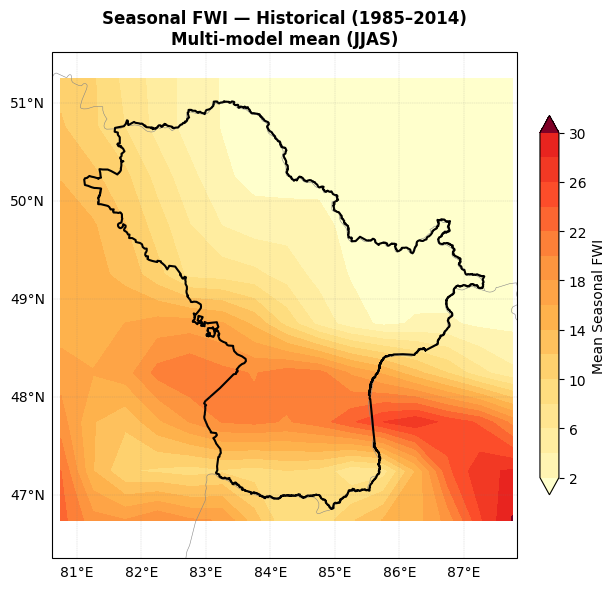

In [ ]:
plot_kaz_map(
    hist_fwi_map, lats, lons, eko_dissolved,
    title=(f'Seasonal FWI — Historical ({HIST_START}–{HIST_END})\n'
           f'Multi-model mean ({season_str})'),
    cmap='YlOrRd', vmin=0, vmax=40,
    cbar_label='Mean Seasonal FWI',
    save_path=results_dir / f'{region_id}_FWI_seasonal_hist.png'
)

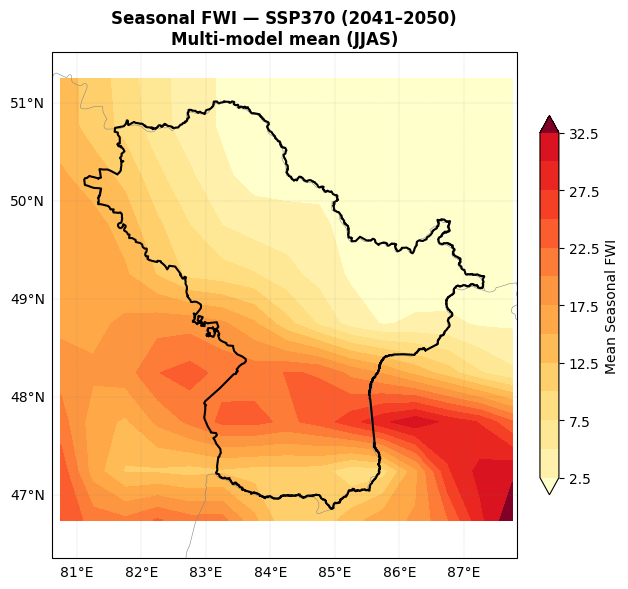

In [ ]:
plot_kaz_map(
    fut_fwi_map, lats, lons, eko_dissolved,
    title=(f'Seasonal FWI — {FUTURE_SCENARIO.upper()} ({FUTURE_START}–{FUTURE_END})\n'
           f'Multi-model mean ({season_str})'),
    cmap='YlOrRd', vmin=0, vmax=40,
    cbar_label='Mean Seasonal FWI',
    save_path=results_dir / f'{region_id}_FWI_seasonal_{FUTURE_SCENARIO}.png'
)

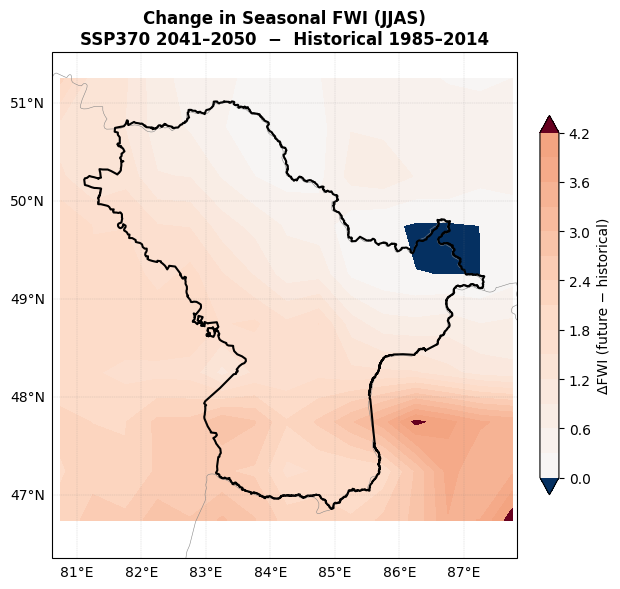

In [ ]:
plot_kaz_map(
    delta_map, lats, lons, eko_dissolved,
    title=(f'Change in Seasonal FWI ({season_str})\n'
           f'{FUTURE_SCENARIO.upper()} {FUTURE_START}–{FUTURE_END}  −  '
           f'Historical {HIST_START}–{HIST_END}'),
    cmap='RdBu_r', vmin=-10, vmax=10,
    cbar_label='ΔFWI (future − historical)',
    save_path=results_dir / f'{region_id}_FWI_delta_{FUTURE_SCENARIO}.png'
)

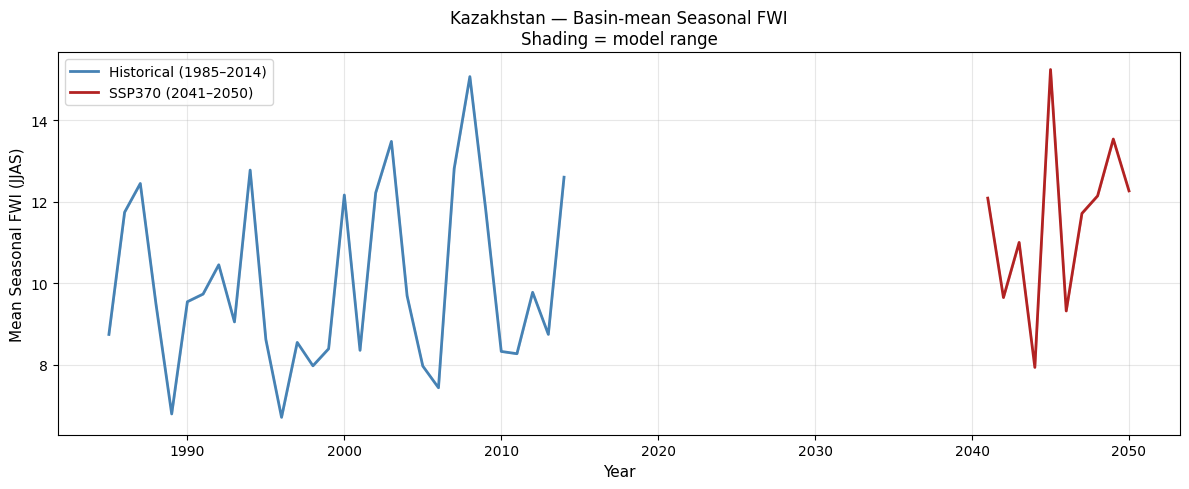

In [ ]:
hist_ts = spatial_mean(hist_seas_stack)  
fut_ts  = spatial_mean(fut_seas_stack)

fig, ax = plt.subplots(figsize=(12, 5))

h_mm  = hist_ts.mean(dim='model').values
h_lo  = hist_ts.min(dim='model').values
h_hi  = hist_ts.max(dim='model').values
h_yrs = hist_ts.year.values
ax.fill_between(h_yrs, h_lo, h_hi, alpha=0.20, color='steelblue')
ax.plot(h_yrs, h_mm, color='steelblue', linewidth=2,
        label=f'Historical ({HIST_START}–{HIST_END})')

f_mm  = fut_ts.mean(dim='model').values
f_lo  = fut_ts.min(dim='model').values
f_hi  = fut_ts.max(dim='model').values
f_yrs = fut_ts.year.values
ax.fill_between(f_yrs, f_lo, f_hi, alpha=0.20, color='firebrick')
ax.plot(f_yrs, f_mm, color='firebrick', linewidth=2,
        label=f'{FUTURE_SCENARIO.upper()} ({FUTURE_START}–{FUTURE_END})')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel(f'Mean Seasonal FWI ({season_str})', fontsize=11)
ax.set_title(f'Kazakhstan — Basin-mean Seasonal FWI\nShading = model range',
              fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / f'{region_id}_FWI_timeseries_{FUTURE_SCENARIO}.png',
             dpi=150)
plt.show()
plt.close()

## Part 2: Fire Season Length

Fire season length = number of days per year with FWI > `FWI_THRESHOLD`.

Results are shown as **best / worst / mean** case across the model ensemble
(multi-model, inter-annual mean ± 1.96 σ), following the original workflow.
Best and worst cases cover approximately 95% of the predicted distribution.

A significant lengthening of the fire season indicates a need to extend
the operational period of wildfire response and prevention resources.

In [ ]:
def fday_scenarios(fday_stack):
    """
    Compute best / worst / mean fire-day maps from a (model, year, lat, lon) stack.
    Best  = mean − 1.96 σ (floored at 0)
    Worst = mean + 1.96 σ
    """
    mm = fday_stack.mean(dim=['model', 'year']).values
    sd = fday_stack.std(dim=['model', 'year']).values
    return (np.maximum(mm - 1.96 * sd, 0.0),   
            mm + 1.96 * sd,                       
            mm)                                   


hist_best, hist_worst, hist_mean = fday_scenarios(hist_fday_stack)
fut_best,  fut_worst,  fut_mean  = fday_scenarios(fut_fday_stack)

# Shared colour scale across both periods
vmax_days = float(
    np.nanmax([
        np.nanpercentile(hist_worst, 97),
        np.nanpercentile(fut_worst,  97)
    ])
)

In [ ]:
def plot_fday_panel(maps, panel_titles, fig_title, save_path):
    """Plot a 3-panel (best / worst / mean) fire-day map."""
    fig, axes = plt.subplots(
        3, 1, figsize=(12, 16),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    for ax, data, ptitle in zip(axes, maps, panel_titles):
        ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                       crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='#888888')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='#888888')
        lon2d, lat2d = np.meshgrid(lons, lats)
        cf = ax.contourf(lon2d, lat2d, data,
                          transform=ccrs.PlateCarree(),
                          cmap='Reds', vmin=0, vmax=vmax_days,
                          levels=15, extend='max')
        plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, shrink=0.75,
                      label=f'Days/year with FWI > {FWI_THRESHOLD}')
        eko_dissolved.boundary.plot(
            ax=ax, transform=ccrs.PlateCarree(),
            color='black', linewidth=1.5)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                           color='gray', alpha=0.4, linestyle='--')
        gl.top_labels = gl.right_labels = False
        ax.set_title(ptitle, fontsize=11, fontweight='bold')

    fig.suptitle(fig_title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

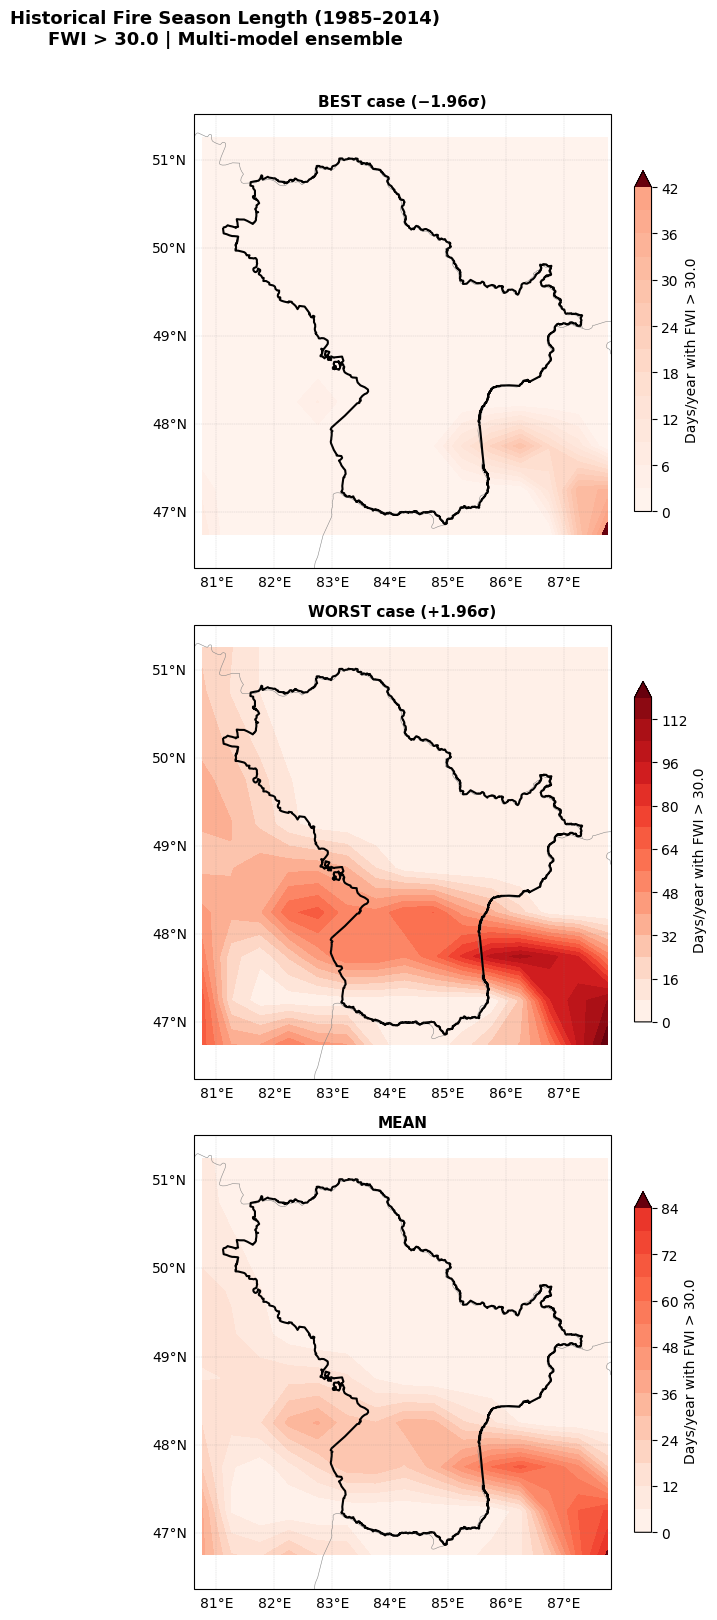

In [ ]:
plot_fday_panel(
    [hist_best, hist_worst, hist_mean],
    ['BEST', 'WORST', 'MEAN'],
    (f'Historical Fire Season Length ({HIST_START}–{HIST_END})\n'
     f'FWI > {FWI_THRESHOLD} | Multi-model ensemble'),
    results_dir / f'{region_id}_FWI_firedays_hist.png'
)

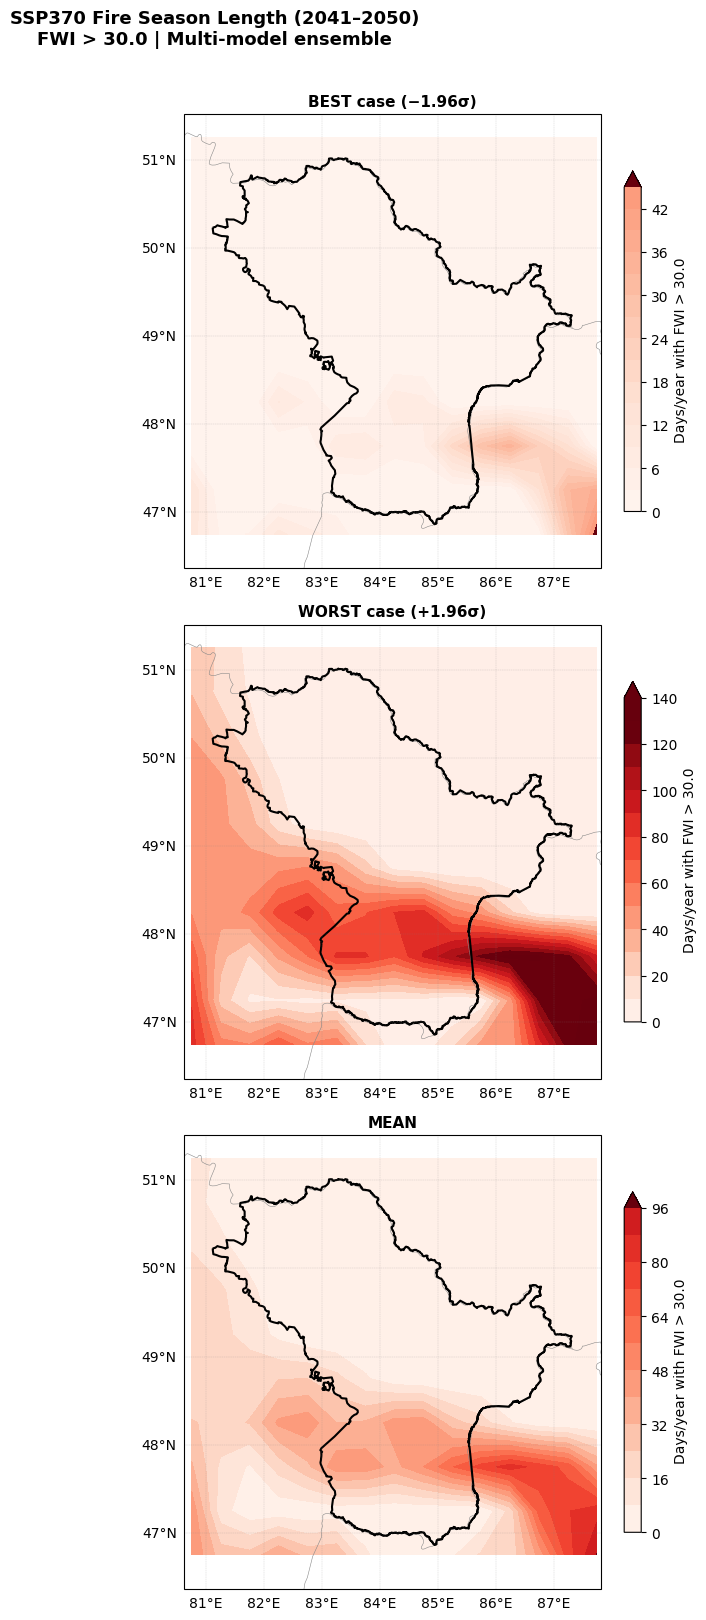

In [ ]:
plot_fday_panel(
    [fut_best, fut_worst, fut_mean],
    ['BEST', 'WORST', 'MEAN'],
    (f'{FUTURE_SCENARIO.upper()} Fire Season Length ({FUTURE_START}–{FUTURE_END})\n'
     f'FWI > {FWI_THRESHOLD} | Multi-model ensemble'),
    results_dir / f'{region_id}_FWI_firedays_{FUTURE_SCENARIO}.png'
)

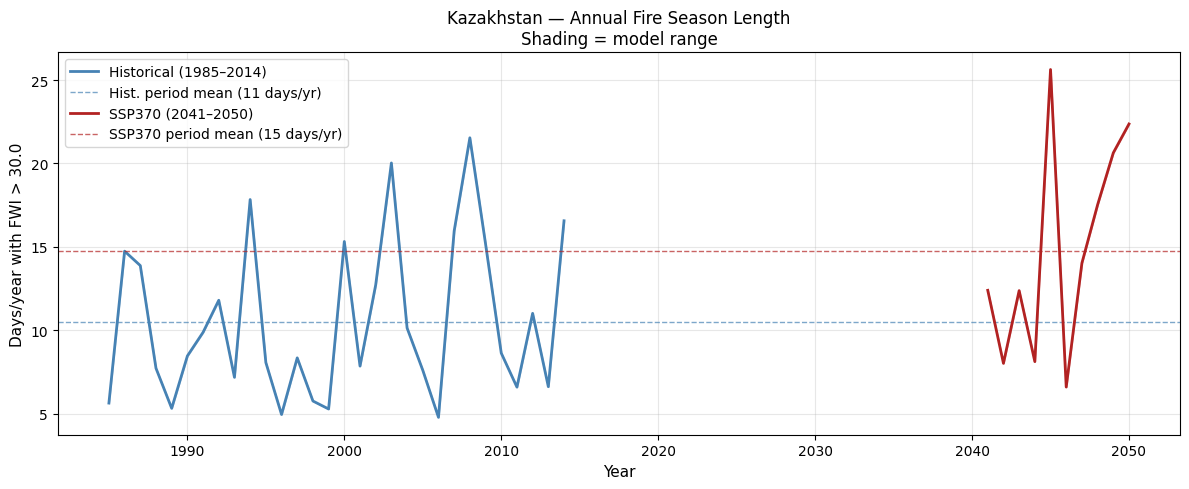

In [ ]:
hist_fday_ts = spatial_mean(hist_fday_stack) 
fut_fday_ts  = spatial_mean(fut_fday_stack)

fig, ax = plt.subplots(figsize=(12, 5))

h_mm  = hist_fday_ts.mean(dim='model').values
h_lo  = hist_fday_ts.min(dim='model').values
h_hi  = hist_fday_ts.max(dim='model').values
h_yrs = hist_fday_ts.year.values

ax.fill_between(h_yrs, h_lo, h_hi, alpha=0.20, color='steelblue')
ax.plot(h_yrs, h_mm, color='steelblue', linewidth=2,
        label=f'Historical ({HIST_START}–{HIST_END})')
ax.axhline(float(h_mm.mean()), color='steelblue', linestyle='--',
            linewidth=1, alpha=0.7,
            label=f'Hist. period mean ({h_mm.mean():.0f} days/yr)')

f_mm  = fut_fday_ts.mean(dim='model').values
f_lo  = fut_fday_ts.min(dim='model').values
f_hi  = fut_fday_ts.max(dim='model').values
f_yrs = fut_fday_ts.year.values

ax.fill_between(f_yrs, f_lo, f_hi, alpha=0.20, color='firebrick')
ax.plot(f_yrs, f_mm, color='firebrick', linewidth=2,
        label=f'{FUTURE_SCENARIO.upper()} ({FUTURE_START}–{FUTURE_END})')
ax.axhline(float(f_mm.mean()), color='firebrick', linestyle='--',
            linewidth=1, alpha=0.7,
            label=f'{FUTURE_SCENARIO.upper()} period mean ({f_mm.mean():.0f} days/yr)')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel(f'Days/year with FWI > {FWI_THRESHOLD}', fontsize=11)
ax.set_title(f'Kazakhstan — Annual Fire Season Length\n'
             f'Shading = model range', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / f'{region_id}_FWI_firedays_ts_{FUTURE_SCENARIO}.png',
             dpi=150)
plt.show()
plt.close()

## Results summary

Outputs saved to `results/`:
- `KAZ_EKO_FWI_seasonal_hist.png` — Historical mean seasonal FWI map
- `KAZ_EKO_FWI_seasonal_{scenario}.png` — Future mean seasonal FWI map
- `KAZ_EKO_FWI_delta_{scenario}.png` — Change in seasonal FWI
- `KAZ_EKO_FWI_timeseries_{scenario}.png` — Basin-mean FWI time series
- `KAZ_EKO_FWI_firedays_hist.png` — Historical fire season length (3 panels)
- `KAZ_EKO_FWI_firedays_{scenario}.png` — Future fire season length (3 panels)
- `KAZ_EKO_FWI_firedays_ts_{scenario}.png` — Annual fire season length time series

Intermediate annual statistics (per model, per scenario) are cached in
`data/isimip_clipped/fwi_stats_*.nc` and reused on rerun.

**Kazakhstan-specific interpretation notes**:
- FWI danger thresholds in this notebook follow EFFIS (European) calibration.
  Regions of Kazakhstan's steppe may show moderate EFFIS-class FWI values
  even during active fire periods due to different fuel types.
- The fire season window (JJAS) may underrepresent spring steppe fires
  (April–May). Run again with `FIRE_SEASON_MONTHS = [4,5,6,7,8,9]` to
  compare.
- Projected increases in fire season length in southern and central
  Kazakhstan are consistent with general drying trends under elevated
  SSP scenarios across Central Asia.